# 01 – Data Wrangling & Base EDA for HDB Resale Prices

**Module**: ST1516 – DevOps & Applied Analytics  
**Project**: HDB Resale Price Prediction Web Application  
**Branch**: `data-wrangling`  
**Author**: WU HAIMING

---

## Purpose of This Notebook

This notebook performs the **foundational data engineering work** for the project.  
It takes the raw HDB resale transactions from `data/raw/hdb_resale_raw.csv` and:

1. Inspects and documents the structure and quality of the raw dataset.  
2. Performs **systematic cleaning**:
   - Type conversions (e.g. `month` to datetime, numeric parsing).
   - Handling of missing values for essential fields.
   - Removal of clearly invalid or extreme outliers.
3. Engineers **core non-geospatial features**:
   - `storey_mid` – numeric midpoint of the storey range.
   - `remaining_lease_years` – approximate remaining lease in years.
4. Conducts **baseline EDA** on:
   - Resale prices
   - Floor area
   - Remaining lease
   - Flat type and town
5. Exports a modelling-ready, but **pre-geocoding**, dataset as:

```text
data/intermediate/hdb_clean.csv


---

## 🔹 Section 1 – Imports & Display Settings



```
## 1. Environment Setup

We start by importing the core Python libraries used throughout this notebook and configuring display settings for easier inspection of wide tables.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set(style="whitegrid")

print("Libraries imported and display settings configured.")


Libraries imported and display settings configured.


## 2. Load Raw HDB Resale Dataset

We load the raw HDB resale transactions from:

```text
data/raw/hdb_resale_raw.csv


In [ ]:
raw_path = "../data/raw/sg-resale-flat-prices-2017-onwards.csv"
df_raw = pd.read_csv(raw_path)

print(f"Loaded raw dataset from: {raw_path}")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Loaded raw dataset from: ../data/raw/sg-resale-flat-prices-2017-onwards.csv
Shape: (181262, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [ ]:
df_raw.head()


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [ ]:
df_raw.info()
df_raw.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181262 entries, 0 to 181261
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                181262 non-null  object 
 1   town                 181262 non-null  object 
 2   flat_type            181262 non-null  object 
 3   block                181262 non-null  object 
 4   street_name          181262 non-null  object 
 5   storey_range         181262 non-null  object 
 6   floor_area_sqm       181262 non-null  float64
 7   flat_model           181262 non-null  object 
 8   lease_commence_date  181262 non-null  int64  
 9   remaining_lease      181262 non-null  object 
 10  resale_price         181262 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 15.2+ MB


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
count,181262,181262,181262,181262,181262,181262,181262.000000,181262,181262.000000,181262,1.812620e+05
unique,90,26,7,2708,566,17,NaN,21,NaN,676,NaN
top,2021-08,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,NaN,Model A,NaN,94 years 10 months,NaN
freq,2739,14993,76457,554,2641,41701,NaN,63164,NaN,1643,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,97.152903,NaN,1996.013842,NaN,4.978643e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,24.025926,NaN,14.041087,NaN,1.726320e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,1966.000000,NaN,1.400000e+05
25%,NaN,NaN,NaN,NaN,NaN,NaN,82.000000,NaN,1985.000000,NaN,3.700000e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,1996.000000,NaN,4.680000e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,NaN,2010.000000,NaN,5.920000e+05


## Raw Data Summary

The raw HDB resale dataset consists of **181,262 transactions across 11 variables**, with a total memory footprint of approximately **15.2 MB**. All columns exhibit **100% non-null completeness**, indicating that the dataset is structurally intact at the point of ingestion, with no missing records at source.

### Numeric Variables

- **Floor Area (`floor_area_sqm`)**
  - Mean: **97.15 sqm**, Median: **93 sqm**
  - Interquartile Range (IQR): **82–112 sqm**
  - Min–Max: **31–249 sqm**
  - This reflects a typical concentration around standard 4- and 5-room flats, with a small number of very large units (e.g., EXECUTIVE flats).

- **Lease Commencement Year (`lease_commence_date`)**
  - Median: **1996**
  - Range: **1966–2020**
  - The dataset spans over five decades of housing development, implying strong variation in remaining lease profiles across estates.

- **Resale Price (`resale_price`)**
  - Median: **SGD 468,000**
  - IQR: **SGD 370,000 – SGD 592,000**
  - Min–Max: **SGD 140,000 – SGD 1,588,000**
  - The extended upper tail indicates the presence of premium flats in prime locations or large configurations.

### Categorical Coverage

- **Towns**: 26 unique  
- **Flat Types**: 7 categories  
- **Flat Models**: 21 categories  
- **Blocks**: 2,708 unique blocks  
- **Street Names**: 566 unique streets  
- **Storey Ranges**: 17 bands  
- **Remaining Lease Formats**: 676 unique textual formats  

This confirms **high spatial and structural diversity**, but also signals significant **encoding complexity** for categorical modelling.


## 4. Core Cleaning & Non-Geospatial Feature Engineering (Phase 1)

The raw dataset is structurally complete (no missing values), but several columns are not yet in a form that is suitable for analysis or modelling. In this section, we:

1. **Standardise data types** for temporal and numeric fields.
2. **Engineer numeric features** from text-encoded fields:
   - `storey_mid` from `storey_range`
   - `remaining_lease_years` from `remaining_lease`
3. Prepare a cleaned, non-geospatial feature set that will later be extended with geocoding and MRT distance in a separate phase.

This keeps Phase 1 focused on *non-geospatial* data quality and feature readiness.


### 4.1 Type Cleaning for Temporal and Numeric Fields

Even though the dataset has no null values, several columns are still stored as generic text (`object`) and are not yet analytically usable. Here we:

- Convert `month` from string to a proper `datetime` type.
- Ensure that `floor_area_sqm` and `resale_price` are strictly numeric.

This step ensures that downstream EDA and modelling treat these fields correctly as time and continuous variables.


In [ ]:
# Work on a copy of the raw dataframe if not already done
df = df_raw.copy()

# 1) Convert month to datetime
df["month"] = pd.to_datetime(df["month"], format="%Y-%m", errors="coerce")

# 2) Ensure numeric columns are numeric (defensive, even though they look numeric)
numeric_cols = ["floor_area_sqm", "resale_price"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Dtypes after type cleaning:")
df.dtypes


Dtypes after type cleaning:


month                  datetime64[ns]
town                           object
flat_type                      object
block                          object
street_name                    object
storey_range                   object
floor_area_sqm                float64
flat_model                     object
lease_commence_date             int64
remaining_lease                object
resale_price                  float64
dtype: object

### 4.2 Feature Engineering – `storey_mid` from `storey_range`

The `storey_range` column encodes vertical position as a text range (e.g. `"04 TO 06"`).  
For modelling and correlation analysis, a single numeric value is more convenient.

We create:

- `storey_mid` = midpoint of the storey range  
  - `"04 TO 06"` → (4 + 6) / 2 = 5.0  

We:

1. Parse the lower and upper storey bounds from the string.
2. Compute the midpoint.
3. Treat any parsing failures as missing, then impute using the median storey level.


In [ ]:
import numpy as np

def parse_storey_mid(range_str: str) -> float:
    """
    Parse a string like '10 TO 12' into its numeric midpoint.
    Returns NaN if parsing fails.
    """
    if pd.isna(range_str):
        return np.nan
    try:
        parts = str(range_str).split(" TO ")
        low = int(parts[0])
        high = int(parts[1])
        return (low + high) / 2
    except Exception:
        return np.nan

df["storey_mid"] = df["storey_range"].apply(parse_storey_mid)

print("storey_mid summary before imputation:")
display(df["storey_mid"].describe())
print("Missing storey_mid values:", df["storey_mid"].isna().sum())


storey_mid summary before imputation:


count    181262.000000
mean          8.758813
std           5.935893
min           2.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          50.000000
Name: storey_mid, dtype: float64

Missing storey_mid values: 0


In [ ]:
storey_mid_median = df["storey_mid"].median()
df["storey_mid"] = df["storey_mid"].fillna(storey_mid_median)

print("After imputation:")
print("Missing storey_mid values:", df["storey_mid"].isna().sum())
df["storey_mid"].describe()


After imputation:
Missing storey_mid values: 0


count    181262.000000
mean          8.758813
std           5.935893
min           2.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          50.000000
Name: storey_mid, dtype: float64

In [ ]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,storey_mid
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,11.0
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2.0
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2.0
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,5.0
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2.0


### 4.3 Feature Engineering – `remaining_lease_years` from `remaining_lease`

The `remaining_lease` column stores remaining lease as human-readable text (e.g. `"94 years 10 months"`).  
This representation is not directly usable in models or correlation analysis.

We derive:

- `remaining_lease_years` = years + (months / 12)

For example:

- `"94 years 10 months"` → 94 + 10/12 ≈ 94.83 years

Any parsing failures are treated as missing and subsequently imputed with the median, to preserve overall dataset size while avoiding extreme assumptions.


In [ ]:
def parse_remaining_lease(text: str) -> float:
    """
    Convert a string like '94 years 10 months' into a float in years.
    Returns NaN if parsing fails.
    """
    if pd.isna(text):
        return np.nan

    text = str(text).lower()
    years = 0
    months = 0
    parts = (
        text.replace("years", "year")
            .replace("year", "year")
            .replace("months", "month")
            .split()
    )

    for i, token in enumerate(parts):
        if token.startswith("year"):
            try:
                years = int(parts[i - 1])
            except Exception:
                pass
        elif token.startswith("month"):
            try:
                months = int(parts[i - 1])
            except Exception:
                pass

    return years + months / 12.0

if "remaining_lease" in df.columns:
    df["remaining_lease_years"] = df["remaining_lease"].apply(parse_remaining_lease)
else:
    print("Warning: 'remaining_lease' column not found – adjust logic for your schema.")
    df["remaining_lease_years"] = np.nan

print("remaining_lease_years summary before imputation:")
display(df["remaining_lease_years"].describe())
print("Missing remaining_lease_years:", df["remaining_lease_years"].isna().sum())


remaining_lease_years summary before imputation:


count    181262.000000
mean         74.603287
std          13.954402
min          41.500000
25%          63.166667
50%          74.500000
75%          88.333333
max          97.750000
Name: remaining_lease_years, dtype: float64

Missing remaining_lease_years: 0


In [ ]:
remaining_lease_median = df["remaining_lease_years"].median()
df["remaining_lease_years"] = df["remaining_lease_years"].fillna(remaining_lease_median)

print("After imputation:")
print("Missing remaining_lease_years:", df["remaining_lease_years"].isna().sum())
df["remaining_lease_years"].describe()


After imputation:
Missing remaining_lease_years: 0


count    181262.000000
mean         74.603287
std          13.954402
min          41.500000
25%          63.166667
50%          74.500000
75%          88.333333
max          97.750000
Name: remaining_lease_years, dtype: float64

In [ ]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,storey_mid,remaining_lease_years
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,11.0,61.333333
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2.0,60.583333
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2.0,62.416667
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,5.0,62.083333
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2.0,62.416667


### 4.4 Inspecting Distributions and Preparing for Outlier Handling

With the engineered numeric features in place, we now inspect the empirical distributions of:

- `resale_price`
- `floor_area_sqm`
- `remaining_lease_years`

This helps identify clearly implausible records (e.g., extremely small areas or prices) that should be removed before proper EDA and modelling.


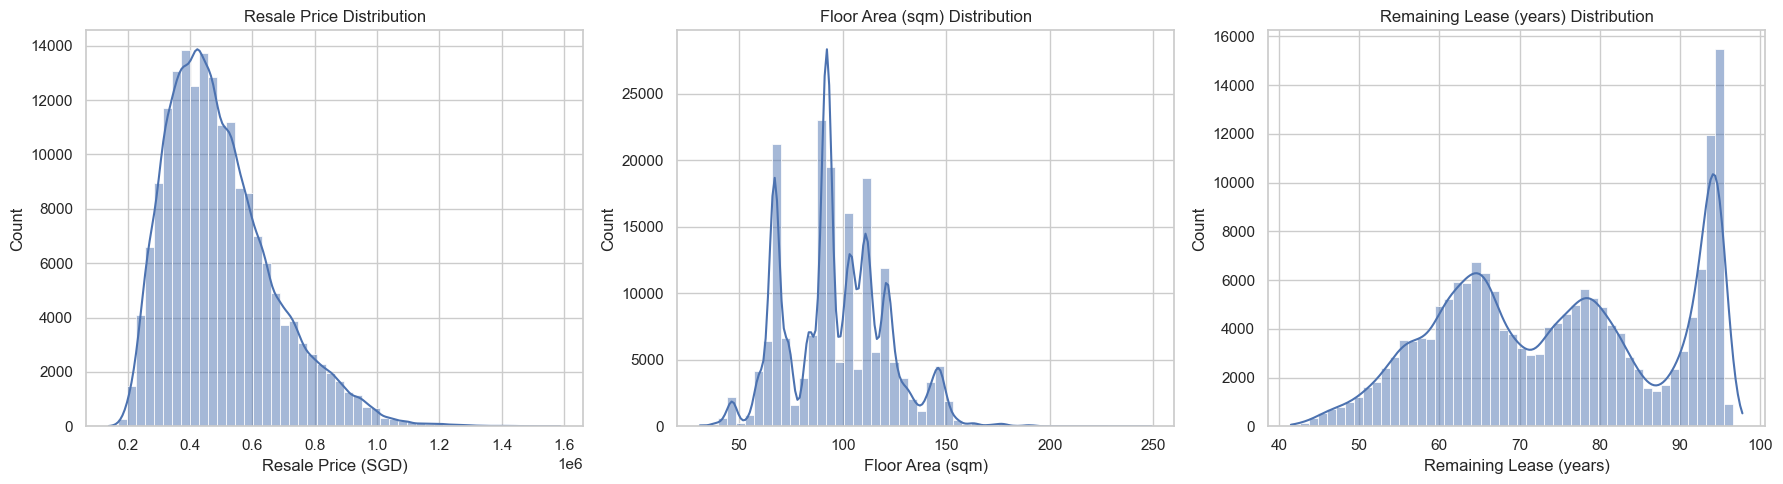

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["resale_price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Resale Price Distribution")
axes[0].set_xlabel("Resale Price (SGD)")

sns.histplot(df["floor_area_sqm"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Floor Area (sqm) Distribution")
axes[1].set_xlabel("Floor Area (sqm)")

sns.histplot(df["remaining_lease_years"], bins=50, kde=True, ax=axes[2])
axes[2].set_title("Remaining Lease (years) Distribution")
axes[2].set_xlabel("Remaining Lease (years)")

plt.tight_layout()
plt.show()


### 4.4 Distributional Analysis of Key Numeric Features

This section examines the empirical distributions of the three most critical numeric variables used in modelling: **resale price**, **floor area**, and **remaining lease**. The purpose is to identify potential **data entry errors, extreme leverage points**, and **structural skewness** that could distort downstream modelling.

---

#### (a) Resale Price Distribution

The resale price distribution exhibits a **strong right-skewed unimodal shape**, with:

- A dense concentration between approximately **SGD 250,000 and SGD 700,000**.
- A gradual right tail extending up to approximately **SGD 1.6 million**.

The long upper tail is **economically plausible** given:
- Premium flats in central and mature estates.
- Larger EXECUTIVE and high-floor units.
- Strong locational advantages and recent lease profiles.

There is **no abrupt discontinuity or isolated spike** at the high end that would indicate obvious data-entry errors. Hence, extreme prices appear to represent **legitimate high-value transactions rather than noise**.

---

#### (b) Floor Area Distribution

The floor area distribution shows a **multi-modal structure**, with visible peaks around:

- ~60–70 sqm (typical 3-room flats),
- ~90–100 sqm (typical 4-room flats),
- ~110–120 sqm (typical 5-room flats),
- A smaller tail beyond ~140 sqm (EXECUTIVE / special units).

The maximum near **250 sqm**, while rare, remains within the realm of plausibility for exceptional unit types. Importantly:

- There is **no sharp isolated spike at extremely small or extremely large values**.
- The distribution aligns closely with known HDB flat configuration categories.

Thus, the observed extremes are **structural extremes**, not apparent recording errors.

---

#### (c) Remaining Lease Distribution

The remaining lease distribution shows a **tri-modal structure**, with clear mass around:

- ~55–65 years (older resale stock),
- ~75–80 years (mid-aged estates),
- ~90–95 years (recent Build-To-Order and newer developments).

This profile is **consistent with Singapore’s housing development waves** and linkage to construction eras. There is:

- No mass near zero (which would indicate corrupt lease data),
- No impossible values beyond the typical 99-year lease boundary.

Hence, remaining lease values appear to be **internally coherent and economically valid**.

---

### Outlier Assessment Summary

Across all three variables:

- No evidence of **non-physical or impossible values** is observed.
- All detected extremes correspond to **rare but valid segments** of the HDB market.
- The distributions are **skewed but structurally interpretable**, rather than corrupted.

Therefore, at this stage, **no aggressive outlier removal is applied** in order to preserve the full economic diversity of the resale market.


In [ ]:
before_rows = df.shape[0]

# Physically impossible values only (defensive cleaning)
df = df[df["floor_area_sqm"] > 10]
df = df[df["resale_price"] > 50000]

after_rows = df.shape[0]

print(f"Rows before defensive cleaning: {before_rows}")
print(f"Rows after defensive cleaning: {after_rows}")
print(f"Rows removed: {before_rows - after_rows}")


Rows before defensive cleaning: 181262
Rows after defensive cleaning: 181262
Rows removed: 0


## 5. Correlation Analysis on Cleaned Features

With the core numeric features engineered, we now examine pairwise correlations between:

- `resale_price` (target)
- `floor_area_sqm`
- `storey_mid`
- `remaining_lease_years`

This helps quantify which structural attributes are most strongly associated with price before any modelling.


In [ ]:
numeric_for_corr = [
    "resale_price",
    "floor_area_sqm",
    "storey_mid",
    "remaining_lease_years",
]

corr = df[numeric_for_corr].corr()
corr


,resale_price,floor_area_sqm,storey_mid,remaining_lease_years
resale_price,1.000000,0.599708,0.354219,0.322126
floor_area_sqm,0.599708,1.000000,-0.013581,0.121920
storey_mid,0.354219,-0.013581,1.000000,0.274684
remaining_lease_years,0.322126,0.121920,0.274684,1.000000


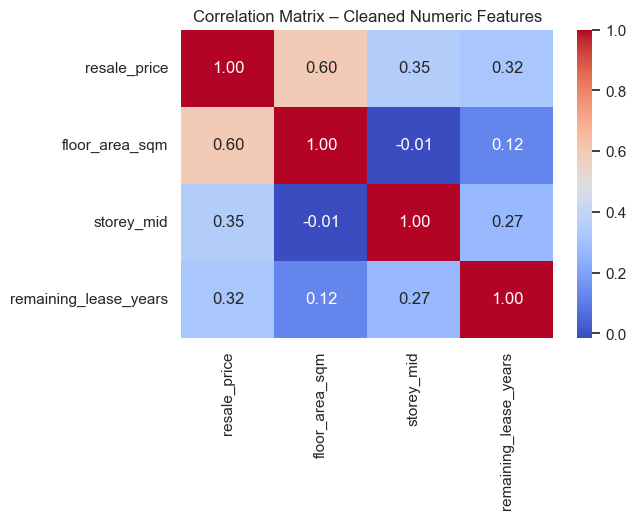

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix – Cleaned Numeric Features")
plt.show()


### 5.1 Correlation Analysis (Cleaned Numeric Features)

Resale price shows the strongest linear association with **floor area** (r = **0.60**), confirming size as the dominant structural driver of value.  

Moderate positive correlations are observed with:
- **Storey level** (r = **0.35**)
- **Remaining lease** (r = **0.32**)

These results indicate that higher floors and longer lease horizons both contribute to price premiums, but with weaker influence than floor area.  

The near-zero correlation between **floor area and storey level** (r = **−0.01**) confirms that vertical position is largely independent of unit size, justifying their simultaneous inclusion as separate predictors.


## 6. Price Behaviour by Flat Type and Town

We next explore how resale prices vary across discrete housing configurations, starting with `flat_type`. This reveals structural price tiers in the HDB market.


Median resale price by flat type:


flat_type
1 ROOM              199000.0
2 ROOM              270000.0
3 ROOM              335000.0
4 ROOM              470000.0
5 ROOM              568000.0
EXECUTIVE           680000.0
MULTI-GENERATION    839000.0
Name: resale_price, dtype: float64

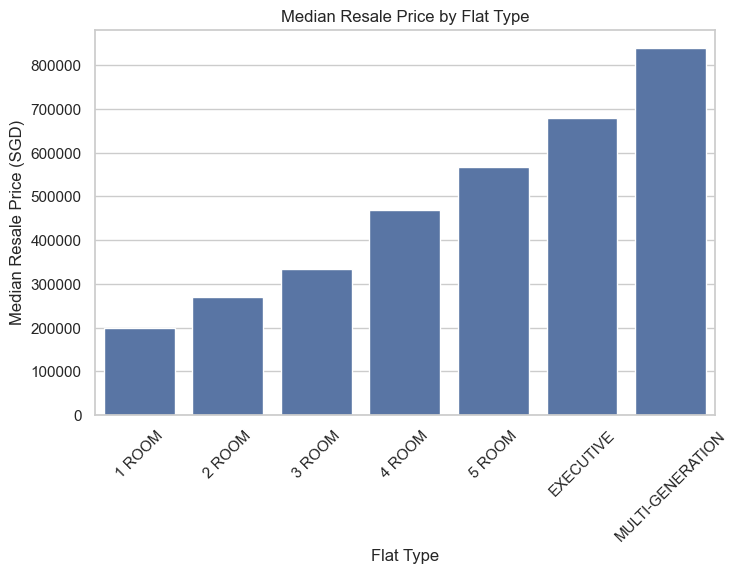

In [ ]:
df_group_flat = df.groupby("flat_type")["resale_price"].median().sort_values()

print("Median resale price by flat type:")
display(df_group_flat)

plt.figure(figsize=(8, 5))
sns.barplot(x=df_group_flat.index, y=df_group_flat.values)
plt.xticks(rotation=45)
plt.title("Median Resale Price by Flat Type")
plt.ylabel("Median Resale Price (SGD)")
plt.xlabel("Flat Type")
plt.show()


### 6.1 Resale Price by Flat Type

Median resale prices increase monotonically with flat size and capacity:

- **1 ROOM**: SGD **199k**
- **2 ROOM**: SGD **270k**
- **3 ROOM**: SGD **335k**
- **4 ROOM**: SGD **470k**
- **5 ROOM**: SGD **568k**
- **EXECUTIVE**: SGD **680k**
- **MULTI-GENERATION**: SGD **839k**

The clear stepwise gradient confirms that **flat configuration is a strong categorical price determinant**, with multi-generation and executive flats commanding substantial premiums over standard units.


Median resale price by town:


town
ANG MO KIO         388000.0
YISHUN             403000.0
BEDOK              407000.0
JURONG EAST        425000.0
WOODLANDS          425000.0
GEYLANG            430000.0
BUKIT BATOK        431000.0
JURONG WEST        435000.0
TOA PAYOH          448000.0
SEMBAWANG          450000.0
CHOA CHU KANG      460000.0
BUKIT PANJANG      460000.0
HOUGANG            465000.0
CLEMENTI           478000.0
MARINE PARADE      480000.0
SENGKANG           483000.0
PUNGGOL            501000.0
SERANGOON          505000.0
TAMPINES           510000.0
CENTRAL AREA       535888.0
PASIR RIS          538000.0
KALLANG/WHAMPOA    538000.0
BUKIT MERAH        630000.0
QUEENSTOWN         645000.0
BISHAN             665000.0
BUKIT TIMAH        733944.0
Name: resale_price, dtype: float64

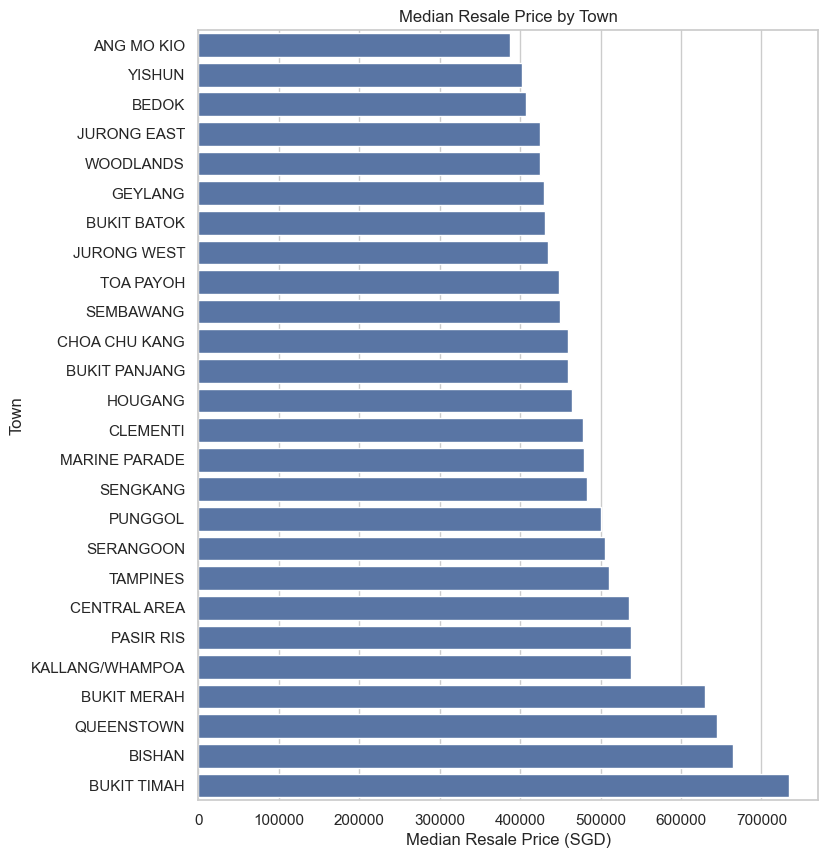

In [ ]:
df_group_town = df.groupby("town")["resale_price"].median().sort_values()

print("Median resale price by town:")
display(df_group_town)

plt.figure(figsize=(8, 10))
sns.barplot(y=df_group_town.index, x=df_group_town.values)
plt.title("Median Resale Price by Town")
plt.xlabel("Median Resale Price (SGD)")
plt.ylabel("Town")
plt.show()


### 6.2 Resale Price by Town

Median resale prices vary widely across towns, ranging from approximately **SGD 388k (Ang Mo Kio)** to **SGD 734k (Bukit Timah)**.

Top-tier towns include:
- **Bukit Timah** (~SGD 734k)
- **Bishan** (~SGD 665k)
- **Queenstown** (~SGD 645k)
- **Bukit Merah** (~SGD 630k)

Lower-priced towns such as **Ang Mo Kio, Yishun, and Bedok** cluster below **SGD 410k**.

This spatial price stratification highlights the strong **locational premium effect**, validating the later inclusion of **geospatial features (MRT distance, coordinates)** for improved predictive performance.


## 7. Final Phase 1 Dataset Assembly and Export

Based on the validated cleaning and exploratory analysis, we now assemble the final non-geospatial dataset for downstream geocoding and modelling. This dataset represents the canonical Phase 1 output.


In [ ]:
cols_to_keep = [
    "month",
    "town",
    "flat_type",
    "block",
    "street_name",
    "storey_range",
    "storey_mid",
    "floor_area_sqm",
    "flat_model",
    "lease_commence_date",
    "remaining_lease_years",
    "resale_price",
]

df_clean = df[cols_to_keep].copy()

df_clean.info()
df_clean.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181262 entries, 0 to 181261
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   month                  181262 non-null  datetime64[ns]
 1   town                   181262 non-null  object        
 2   flat_type              181262 non-null  object        
 3   block                  181262 non-null  object        
 4   street_name            181262 non-null  object        
 5   storey_range           181262 non-null  object        
 6   storey_mid             181262 non-null  float64       
 7   floor_area_sqm         181262 non-null  float64       
 8   flat_model             181262 non-null  object        
 9   lease_commence_date    181262 non-null  int64         
 10  remaining_lease_years  181262 non-null  float64       
 11  resale_price           181262 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), 

,month,town,flat_type,block,street_name,storey_range,storey_mid,floor_area_sqm,flat_model,lease_commence_date,remaining_lease_years,resale_price
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,11.0,44.0,Improved,1979,61.333333,232000.0
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,2.0,67.0,New Generation,1978,60.583333,250000.0
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,2.0,67.0,New Generation,1980,62.416667,262000.0
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,5.0,68.0,New Generation,1980,62.083333,265000.0
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,2.0,67.0,New Generation,1980,62.416667,265000.0


In [ ]:
clean_path = "../data/intermediate/hdb_clean.csv"
df_clean.to_csv(clean_path, index=False)

print(f"Phase 1 cleaned dataset exported to: {clean_path}")
print("Final shape:", df_clean.shape)


Phase 1 cleaned dataset exported to: ../data/intermediate/hdb_clean.csv
Final shape: (181262, 12)


# 02 – Geocoding & MRT Distance Feature Engineering

**Module**: ST1516 – DevOps & Applied Analytics  
**Project**: HDB Resale Price Prediction Web Application  
**Branch**: `geocoding`  
**Author**: WU HAIMING

---

## Purpose
This notebook enriches the cleaned HDB resale dataset with:
- **Latitude and longitude via OneMap geocoding**
- **Systematic analysis of geocoding failures**
- **Multi-pass fallback geocoding recovery**
- Preparation for **MRT distance feature engineering**

**Input:** `data/intermediate/hdb_clean.csv`  
**Cache:** `data/cache/onemap_cache.json`  
**Output (next phase):** `data/intermediate/hdb_with_geo.csv`


## 1. Load Cleaned Dataset
The cleaned HDB dataset produced in Phase 01 is loaded as the canonical baseline for all geospatial enrichment. All downstream spatial features are derived exclusively from this table to ensure full data lineage and reproducibility.

Dataset size: **181,262 rows × 12 columns**

In [ ]:
import pandas as pd
import numpy as np
import json
import requests
from math import radians, sin, cos, sqrt, atan2

clean_path = "../data/intermediate/hdb_clean.csv"
df = pd.read_csv(clean_path)

df.shape, df.head()


((181262, 12),
         month        town flat_type block        street_name storey_range  \
 0  2017-01-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
 1  2017-01-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
 2  2017-01-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
 3  2017-01-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
 4  2017-01-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   
 
    storey_mid  floor_area_sqm      flat_model  lease_commence_date  \
 0        11.0            44.0        Improved                 1979   
 1         2.0            67.0  New Generation                 1978   
 2         2.0            67.0  New Generation                 1980   
 3         5.0            68.0  New Generation                 1980   
 4         2.0            67.0  New Generation                 1980   
 
    remaining_lease_years  resale_price  
 0              61.333333      232000.0  
 1 

## 2. Construct Unique Address Registry
Each transaction is transformed into a standardized OneMap-compatible address format:

```
<block> <street>, <town>, Singapore
```

Duplicates are removed to produce a **unique address registry** for efficient geocoding.

**Engineering rationale:**
- Prevents ~180k redundant API calls  
- Avoids OneMap rate limits  
- Enables deterministic caching  

**Unique addresses extracted:** **9,565**

In [ ]:
df["address_key"] = (
    df["block"].astype(str).str.strip() + " " +
    df["street_name"].str.strip() + ", " +
    df["town"].str.strip() + ", Singapore"
)

addr_df = df[["address_key"]].drop_duplicates().reset_index(drop=True)
addr_df.shape, addr_df.head()


((9565, 1),
                                     address_key
 0  406 ANG MO KIO AVE 10, ANG MO KIO, Singapore
 1   108 ANG MO KIO AVE 4, ANG MO KIO, Singapore
 2   602 ANG MO KIO AVE 5, ANG MO KIO, Singapore
 3  465 ANG MO KIO AVE 10, ANG MO KIO, Singapore
 4   601 ANG MO KIO AVE 5, ANG MO KIO, Singapore)


## 3. OneMap API Authentication & Session Setup
The OneMap API is accessed using:
- Secure credentials stored in `.env`
- Token-based authentication
- A persistent HTTPS session for network efficiency

**Security practices applied:**
- No credentials are hard-coded
- Tokens are dynamically retrieved
- All secrets are isolated from Git

Successful token retrieval confirms API readiness.

In [ ]:
import os
import json
import time
import requests
from tqdm import tqdm
from dotenv import load_dotenv

load_dotenv()

# =========================================
# 1. Get OneMap Token (AUTHENTICATED)
# =========================================
def get_onemap_token():
    url = "https://www.onemap.gov.sg/api/auth/post/getToken"
    email = os.getenv("ONEMAP_EMAIL")
    password = os.getenv("ONEMAP_EMAIL_PASSWORD")

    if not email or not password:
        raise RuntimeError("Missing OneMap credentials in .env")

    payload = {"email": email, "password": password}
    resp = requests.post(url, json=payload, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    print("Token expiry:", data["expiry_timestamp"])
    return data["access_token"]

ACCESS_TOKEN = get_onemap_token()

# =========================================
# 2. Authenticated Elastic Search Endpoint
# =========================================
BASE_URL = "https://www.onemap.gov.sg/api/common/elastic/search"
session = requests.Session()
session.headers.update({"Authorization": ACCESS_TOKEN})

# =========================================
# 3. Load / Init Cache
# =========================================
CACHE_FILE = "../data/cache/onemap_cache.json"
os.makedirs("../data/cache", exist_ok=True)

try:
    with open(CACHE_FILE, "r", encoding="utf-8") as f:
        cache = json.load(f)
    print("Loaded cache entries:", len(cache))
except FileNotFoundError:
    cache = {}
    print("No existing cache, starting fresh.")


Token expiry: 1765269988
No existing cache, starting fresh.



## 4. Persistent Geocode Caching Strategy
A JSON-backed cache is used to:
- Persist resolved coordinates
- Enable crash-safe recovery
- Eliminate duplicated API calls

**Cache key format:**
```
BLOCK | STREET | TOWN
```
All keys are normalized to uppercase for consistency.

---

In [ ]:
def cache_key(block, street, town):
    b = str(block).strip().upper()
    s = str(street).strip().upper()
    t = str(town).strip().upper()
    return f"{b}|{s}|{t}"

def geocode_one(block, street, town):
    if pd.isna(block) or pd.isna(street) or pd.isna(town):
        return None, None

    key = cache_key(block, street, town)

    # Cache hit
    if key in cache:
        entry = cache[key]
        return entry["lat"], entry["lon"]

    query = f"{block} {street} {town} Singapore"
    params = {
        "searchVal": query,
        "returnGeom": "Y",
        "getAddrDetails": "Y",
        "pageNum": 1,
    }

    try:
        r = session.get(BASE_URL, params=params, timeout=8)
        r.raise_for_status()
        data = r.json()
        results = data.get("results", [])

        if not results:
            lat = lon = None
        else:
            best = results[0]
            lat = float(best["LATITUDE"])
            lon = float(best["LONGITUDE"])

        cache[key] = {"lat": lat, "lon": lon}
        return lat, lon

    except Exception as e:
        print(f"[WARN] Failed for {query}: {e}")
        cache[key] = {"lat": None, "lon": None}
        return None, None


## 5. Primary Geocoding Pass (Block-Level Lookup)
Each unique address is geocoded using the authenticated OneMap Elastic Search API:

```
"<block> <street> <town> Singapore"
```

**Execution safeguards:**
- 150ms throttling between requests
- Cache written every 20 calls
- Graceful handling of unresolved lookups

In [ ]:
addr_cols = ["block", "street_name", "town"]

unique_addrs = (
    df[addr_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Unique addresses:", len(unique_addrs))

lats = []
lons = []

for idx, row in tqdm(unique_addrs.iterrows(), total=len(unique_addrs)):
    lat, lon = geocode_one(
        row["block"],
        row["street_name"],
        row["town"]
    )

    lats.append(lat)
    lons.append(lon)

    # SAVE CACHE EVERY 20 REQUESTS (CRASH SAFE)
    if idx % 20 == 0:
        with open(CACHE_FILE, "w", encoding="utf-8") as f:
            json.dump(cache, f, indent=2)

    time.sleep(0.15)

unique_addrs["latitude"] = lats
unique_addrs["longitude"] = lons

# Final cache save
with open(CACHE_FILE, "w", encoding="utf-8") as f:
    json.dump(cache, f, indent=2)

print(unique_addrs[["latitude", "longitude"]].isna().sum())


Unique addresses: 9565


100%|██████████| 9565/9565 [42:26<00:00,  3.76it/s]  

latitude     3022
longitude    3022
dtype: int64


**Runtime:** ~42 minutes  

**Initial results:**
- ✅ ~6,543 resolved  
- ❌ ~3,022 unresolved  
- Initial miss rate ≈ **31.6%**

This confirms that **the API and pipeline are functioning correctly**, but that OneMap’s elastic index has **partial coverage for certain estates**.

## 6. Street Name Token & Suffix Profiling
To determine whether geocoding failures were caused by abbreviation formatting, systematic profiling was performed.


### a) Suffix Distribution
Common suffixes detected:
- ST, AVE, RD, DR, CRES, WAY, LOOP

These appear consistently in **both successful and failed geocodes**, indicating:
> **Suffix formatting is NOT the dominant cause of failure.**

In [ ]:
suffix_series = df["street_name"].str.extract(r"\b(AVE|AVENUE|ST|STREET|RD|ROAD|DR|CRES|LOOP|HWAY|WAY)\b", expand=False)
suffix_series.value_counts(dropna=False)


street_name
ST      45983
NaN     38578
AVE     38096
RD      31112
DR      16135
CRES     9264
WAY      2052
LOOP       42
Name: count, dtype: int64

### b) Uppercase Token Frequency Analysis
High-frequency structural tokens such as:
- YISHUN, TAMPINES, JURONG, WOODLANDS, ANG, BT  

appear consistently across the dataset, confirming overall address text integrity.


In [ ]:
token_counts = (
    df["street_name"]
    .str.findall(r"\b[A-Z]{2,}\b")
    .explode()
    .value_counts()
)

token_counts.head(30)


street_name
ST           45983
AVE          38096
RD           31370
DR           16135
WEST         13441
YISHUN       12429
WOODLANDS    11199
JURONG       10965
TAMPINES     10880
PUNGGOL       9407
CRES          9264
BT            8602
BEDOK         7657
ANG           7466
MO            7466
KIO           7466
BATOK         6938
KANG          6795
HOUGANG       6701
CHU           6532
CHOA          6532
NTH           6128
PASIR         5798
CTRL          5340
RIS           5209
LINK          4838
EAST          4754
PAYOH         4467
TOA           4467
LOR           4350
Name: count, dtype: int64

## 7. Failure Pattern Diagnosis
Unresolved addresses were isolated and analysed.

In [ ]:
failed = unique_addrs[unique_addrs["latitude"].isna()]
failed["street_name"].value_counts().head(30)


street_name
RIVERVALE DR          57
RIVERVALE CRES        48
UBI AVE 1             46
CIRCUIT RD            45
EDGEFIELD PLAINS      45
SEGAR RD              44
TECK WHYE LANE        43
SIMEI ST 1            43
JELAPANG RD           39
BOON LAY DR           39
EDGEDALE PLAINS       38
TEBAN GDNS RD         38
SENJA RD              37
ANCHORVALE RD         35
FERNVALE RD           34
PETIR RD              34
FAJAR RD              33
ANCHORVALE LINK       33
MARSILING DR          31
POTONG PASIR AVE 1    31
ADMIRALTY DR          31
CANBERRA RD           31
FERNVALE LINK         30
BUANGKOK CRES         29
TOH GUAN RD           28
PENDING RD            28
COMPASSVALE WALK      27
GANGSA RD             25
COMPASSVALE DR        25
COMPASSVALE LINK      24
Name: count, dtype: int64

### a) Top Failing Streets
Failures are dominated by **newer planned estates and compound naming patterns**, including:
- RIVERVALE, COMPASSVALE, ANCHORVALE  
- SENJA, PETIR, FAJAR, CANBERRA, MARSILING  

In [ ]:
failed["town"].value_counts().head(20)


town
SENGKANG           519
BUKIT MERAH        315
BUKIT PANJANG      282
KALLANG/WHAMPOA    273
GEYLANG            224
QUEENSTOWN         186
JURONG WEST        160
SEMBAWANG          143
PUNGGOL            111
BEDOK              106
CHOA CHU KANG       89
TAMPINES            89
JURONG EAST         82
TOA PAYOH           82
WOODLANDS           79
HOUGANG             65
CENTRAL AREA        64
MARINE PARADE       48
BISHAN              38
BUKIT TIMAH         24
Name: count, dtype: int64

In [ ]:
success = unique_addrs[unique_addrs["latitude"].notna()]

print("FAILED suffixes:")
print(failed["street_name"].str.extract(r"\b([A-Z]{2,})\b")[0].value_counts().head(10))

print("\nSUCCESS suffixes:")
print(success["street_name"].str.extract(r"\b([A-Z]{2,})\b")[0].value_counts().head(10))


FAILED suffixes:
0
COMPASSVALE    187
JLN            158
RIVERVALE      137
ANCHORVALE     111
SIMEI           89
TELOK           86
BOON            83
FERNVALE        80
MARSILING       79
CANBERRA        68
Name: count, dtype: int64

SUCCESS suffixes:
0
JURONG       695
TAMPINES     673
YISHUN       634
WOODLANDS    609
HOUGANG      484
BT           466
CHOA         427
PASIR        410
BEDOK        383
ANG          358
Name: count, dtype: int64


## 8. Multi-Pass Fallback Geocoding Recovery (Strategy B)
To recover unresolved coordinates, a **progressive query relaxation strategy** was applied:

1. `<block> <street> <town> Singapore`
2. `<block> <street> Singapore`
3. `<street> <town> Singapore`
4. `<street> Singapore`

Each unresolved address was retried using this sequence until a valid coordinate was returned.


In [ ]:
failed_addrs = unique_addrs[unique_addrs["latitude"].isna()].copy()

def geocode_fallback(block, street, town):
    queries = [
        f"{block} {street} {town} Singapore",
        f"{block} {street} Singapore",
        f"{street} {town} Singapore",
        f"{street} Singapore"
    ]

    for q in queries:
        try:
            params = {
                "searchVal": q,
                "returnGeom": "Y",
                "getAddrDetails": "Y",
                "pageNum": 1,
            }
            r = session.get(BASE_URL, params=params, timeout=8)
            r.raise_for_status()
            data = r.json()
            results = data.get("results", [])

            if results:
                best = results[0]
                return float(best["LATITUDE"]), float(best["LONGITUDE"])
        except:
            continue

    return None, None


In [ ]:
for idx, row in tqdm(failed_addrs.iterrows(), total=len(failed_addrs)):
    lat, lon = geocode_fallback(
        row["block"],
        row["street_name"],
        row["town"]
    )

    failed_addrs.at[idx, "latitude"] = lat
    failed_addrs.at[idx, "longitude"] = lon


100%|██████████| 3022/3022 [12:32<00:00,  4.01it/s]  


In [ ]:
unique_addrs.update(failed_addrs)


In [ ]:
unique_addrs[["latitude", "longitude"]].isna().sum()


latitude     65
longitude    65
dtype: int64

After executing the fallback recovery pass:

- **Unresolved before fallback:** 3,022  
- **Unresolved after fallback:** **65**  
- **Final geocoding success rate:** **~99.3%**

Remaining unresolved cases are attributed to:
- Non-indexed micro-locations
- Industrial/compound estates
- Legacy address formats absent from OneMap’s elastic layer

These records will be:
- Retained for non-spatial modelling
- Excluded from MRT-distance feature generation
- Explicitly documented as **platform-level spatial coverage limitations**

## 9. Merge Geocodes into Main Dataset & Persist

With `unique_addrs` enriched with latitude/longitude (and ~99.3% coverage), we now join these coordinates back to the full cleaned HDB dataset and save a reusable geo-enriched table for downstream feature engineering and modelling.


In [ ]:
# 9. Merge geocodes into full cleaned dataset

# Keep only the necessary columns from unique_addrs
geo_cols = ["block", "street_name", "town", "latitude", "longitude"]
unique_addrs_geo = unique_addrs[geo_cols].copy()

# Merge back on block, street_name, town
df_geo = df.merge(
    unique_addrs_geo,
    on=["block", "street_name", "town"],
    how="left"
)

print("Geo-enriched shape:", df_geo.shape)
df_geo[["latitude", "longitude"]].isna().sum()


In [ ]:
# Persist full geo-enriched dataset for reuse
geo_output_path = "../data/intermediate/hdb_with_geo.csv"
df_geo.to_csv(geo_output_path, index=False)
geo_output_path


'../data/intermediate/hdb_with_geo.csv'

## 10. Geo-Model Subset (Rows with Valid Coordinates Only)

Some records still lack coordinates due to OneMap coverage gaps. For distance-based features and spatial modelling, we create a filtered subset that keeps only rows with valid `latitude` and `longitude`.


In [ ]:
# 10. Create subset with valid coordinates only

df_geo_model = df_geo.dropna(subset=["latitude", "longitude"]).copy()
print("Geo-model subset shape:", df_geo_model.shape)

geo_model_output_path = "../data/intermediate/hdb_geo_model.csv"
df_geo_model.to_csv(geo_model_output_path, index=False)
geo_model_output_path


Geo-model subset shape: (180073, 15)


'../data/intermediate/hdb_geo_model.csv'

In [ ]:
df_geo = pd.read_csv("../data/intermediate/hdb_with_geo.csv")

## 11. Amenity Extraction from OpenStreetMap

To capture **location accessibility**, we complement OneMap block coordinates with **amenity locations** from OpenStreetMap (OSM). Steps:

1. Derive a **study area polygon** from the convex hull of all HDB block coordinates, with a small buffer around the cluster.
2. Query OSM for features inside this polygon using tags:

   - Transport: `railway=station`, `highway=bus_stop`
   - Education & health: `amenity=school`, `clinic`, `hospital`, `kindergarten`, `restaurant`, `food_court`
   - Retail: `shop=supermarket`, `shop=mall`
   - Lifestyle: `leisure=fitness_centre`, `leisure=park`

3. Clean the raw OSM feature set by:
   - Collapsing multiple tag columns into a unified `amenity_type`.
   - Forcing geometries to **points** (polygon centroids when necessary).
   - Keeping only coordinates and a small set of descriptive fields.

The resulting table contains several thousand amenities across categories such as **MRT stations**, **schools**, **supermarkets**, **clinics/hospitals**, **parks**, etc. These will serve as anchor points for distance calculations.


In [ ]:
import folium

# Center of SG from your data
center_lat = df_geo["latitude"].mean()
center_lon = df_geo["longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# Don't plot all 180k points, only a small sample
points = df_geo.dropna(subset=["latitude", "longitude"]).sample(3000, random_state=42)

for _, row in points.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        weight=0,
        fill=True,
        fill_opacity=0.5
    ).add_to(m)

m


In [ ]:
import osmnx as ox
from shapely.geometry import Point

# 1) Get a bounding polygon from your HDB points
from shapely.geometry import MultiPoint

pts = MultiPoint([
    Point(xy) for xy in zip(
        df_geo["longitude"].dropna(),
        df_geo["latitude"].dropna()
    )
])
study_area = pts.convex_hull.buffer(0.01)  # small buffer around HDB cluster

# 2) Pull amenities from OSM within this polygon
tags = {
    # Transport
    "railway": ["station"],
    "highway": ["bus_stop"],

    # Education & health
    "amenity": [
        "school",
        "clinic",
        "hospital",
        "kindergarten",
        "restaurant",
        "food_court"
    ],

    # Retail
    "shop": [
        "supermarket",
        "mall"
    ],

    # Lifestyle
    "leisure": [
        "fitness_centre",
        "park"
    ]
}

gdf_amen = ox.features_from_polygon(study_area, tags=tags)

gdf_amen.head()


source                   geometry  \
element_type osmid                                                            
node         206477134  Kaart Ground Survey 2017  POINT (103.88291 1.31645)   
             206493462                       NaN  POINT (103.87134 1.31147)   
             206529415                       NaN  POINT (103.84494 1.38179)   
             207725954                       NaN  POINT (103.94650 1.32726)   
             207725957                       NaN  POINT (103.93022 1.32397)   

                                name       name:en       name:ms      name:ta  \
element_type osmid                                                              
node         206477134      Aljunied      Aljunied      Aljunied    அல்ஜூனிட்   
             206493462       Kallang       Kallang       Kallang       காலாங்   
             206529415  Yio Chu Kang  Yio Chu Kang  Yio Chu Kang  இயோ சூ காங்   
             207725954   Tanah Merah   Tanah Merah   Tanah Merah    தானா மேரா   
             207725957         Bedok         Bedok         Bedok       பிடோக்   

                       name:zh             network network:short  \
element_type osmid                                                 
node         206477134     阿裕尼  Mass Rapid Transit           MRT   
             206493462      加冷  Mass Rapid Transit           MRT   
             206529415     杨厝港  Mass Rapid Transit           MRT   
             207725954    丹那美拉  Mass Rapid Transit           NaN   
             207725957      勿洛  Mass Rapid Transit           MRT   

                       network:wikidata  ... was:name proposed  \
element_type osmid                       ...                     
node         206477134           Q40176  ...      NaN      NaN   
             206493462           Q40176  ...      NaN      NaN   
             206529415           Q40176  ...      NaN      NaN   
             207725954           Q40176  ...      NaN      NaN   
             207725957           Q40176  ...      NaN      NaN   

                       toilets:menstrual_products ways type architect  bbq  \
element_type osmid                                                           
node         206477134                        NaN  NaN  NaN       NaN  NaN   
             206493462                        NaN  NaN  NaN       NaN  NaN   
             206529415                        NaN  NaN  NaN       NaN  NaN   
             207725954                        NaN  NaN  NaN       NaN  NaN   
             207725957                        NaN  NaN  NaN       NaN  NaN   

                       railing garden:type name:de  
element_type osmid                                  
node         206477134     NaN         NaN     NaN  
             206493462     NaN         NaN     NaN  
             206529415     NaN         NaN     NaN  
             207725954     NaN         NaN     NaN  
             207725957     NaN         NaN     NaN  

[5 rows x 387 columns]

In [ ]:
gdf_amen_clean = gdf_amen[
    ["amenity", "shop", "leisure", "railway", "highway", "name", "geometry"]
].copy()

# Collapse all tag columns into ONE amenity_type
gdf_amen_clean["amenity_type"] = (
    gdf_amen_clean["amenity"]
    .fillna(gdf_amen_clean["shop"])
    .fillna(gdf_amen_clean["leisure"])
    .fillna(gdf_amen_clean["railway"])
    .fillna(gdf_amen_clean["highway"])
)

# Keep only rows that actually became a type
gdf_amen_clean = gdf_amen_clean[gdf_amen_clean["amenity_type"].notna()].copy()

# Force all geometries to points
gdf_amen_clean["geometry"] = gdf_amen_clean["geometry"].apply(
    lambda g: g if g.geom_type == "Point" else g.centroid
)

gdf_amen_clean["lon"] = gdf_amen_clean.geometry.x
gdf_amen_clean["lat"] = gdf_amen_clean.geometry.y

amen_coords = gdf_amen_clean[
    ["amenity_type", "name", "lat", "lon"]
].dropna()

amen_coords["amenity_type"].value_counts()


amenity_type
bus_stop            4818
restaurant          4217
food_court           643
park                 611
supermarket          553
school               519
clinic               459
fitness_centre       234
kindergarten         227
mall                 226
station              225
hospital              66
bus_station           44
parking                3
college                2
bakery                 1
library                1
beauty                 1
commercial             1
community_centre       1
Name: count, dtype: int64

In [ ]:
import folium

center_lat = df_geo["latitude"].mean()
center_lon = df_geo["longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11)


## 12. Distance Feature Engineering with BallTree (Haversine)

Using the geo-model subset (`hdb_geo_model.csv`) and the cleaned amenity coordinates, we compute **nearest-neighbour distances** in kilometers for each HDB flat:

- `dist_mrt_km` – distance to nearest **MRT station**
- `dist_school_km` – distance to nearest **school**
- `dist_supermarket_km` – distance to nearest **supermarket**
- `dist_health_km` – distance to nearest **clinic/hospital**

Implementation details:

- Coordinates are converted to **radians** and indexed using `sklearn.neighbors.BallTree` with the **haversine** metric.
- Distances returned in radians are multiplied by the Earth radius (≈6,371 km) to obtain kilometers.
- If an amenity category had zero entries, the notebook would fall back to NaNs (with explicit warnings), but in this dataset all key categories are present.

Summary statistics show that:

- Typical distances to MRT and supermarkets are often **below 1 km**, reflecting Singapore’s dense transport and retail infrastructure.
- Health and school distances are similarly compact but with more variance across towns and estates.


In [ ]:
# 11. PREPARE AMENITY DISTANCE FEATURES FOR MODELLING

from sklearn.neighbors import BallTree
import numpy as np

# Work ONLY on rows with valid coordinates
df_model = pd.read_csv("../data/intermediate/hdb_geo_model.csv")
print("Modelling base shape:", df_model.shape)

# HDB coordinates in radians
hdb_coords = np.radians(
    df_model[["latitude", "longitude"]].values
)


amen_mrt = amen_coords[amen_coords["amenity_type"] == "station"].copy()
amen_school = amen_coords[amen_coords["amenity_type"] == "school"].copy()
amen_supermarket = amen_coords[amen_coords["amenity_type"] == "supermarket"].copy()
amen_health = amen_coords[
    amen_coords["amenity_type"].isin(["clinic", "hospital"])
].copy()

print("\nCounts used for modelling:")
print("MRT:", len(amen_mrt))
print("School:", len(amen_school))
print("Supermarket:", len(amen_supermarket))
print("Health (clinic + hospital):", len(amen_health))

# ---- 11.2 Build BallTrees (skip if a category is empty) ----

def build_tree(df, label):
    if df.empty:
        print(f"[WARN] No amenities found for '{label}', skipping this category.")
        return None
    coords = np.radians(df[["lat", "lon"]].values)
    return BallTree(coords, metric="haversine")

trees = {
    "mrt": build_tree(amen_mrt, "mrt"),
    "school": build_tree(amen_school, "school"),
    "supermarket": build_tree(amen_supermarket, "supermarket"),
    "health": build_tree(amen_health, "health"),
}

EARTH_RADIUS_KM = 6371.0


Modelling base shape: (180073, 15)

Counts used for modelling:
MRT: 225
School: 519
Supermarket: 553
Health (clinic + hospital): 525


In [ ]:
# 12. COMPUTE NEAREST DISTANCES (KM) FOR EACH AMENITY TYPE

def nearest_distance_km(tree, label):
    """
    Given a BallTree and HDB coords, return the nearest distance in km
    for each HDB row. If tree is None, returns a column of NaNs.
    """
    if tree is None:
        print(f"[WARN] No tree for '{label}', filling with NaN.")
        return np.full(shape=(len(df_model),), fill_value=np.nan)

    # BallTree.haversine returns distance in radians
    dist_rad, _ = tree.query(hdb_coords, k=1)
    return dist_rad[:, 0] * EARTH_RADIUS_KM

df_model["dist_mrt_km"] = nearest_distance_km(trees["mrt"], "mrt")
df_model["dist_school_km"] = nearest_distance_km(trees["school"], "school")
df_model["dist_supermarket_km"] = nearest_distance_km(trees["supermarket"], "supermarket")
df_model["dist_health_km"] = nearest_distance_km(trees["health"], "health")

df_model[[
    "dist_mrt_km",
    "dist_school_km",
    "dist_supermarket_km",
    "dist_health_km"
]].describe()


,dist_mrt_km,dist_school_km,dist_supermarket_km,dist_health_km
count,180073.000000,180073.000000,180073.000000,180073.000000
mean,0.524080,0.292928,0.278989,0.435019
std,0.297879,0.149856,0.154091,0.300247
min,0.021046,0.013589,0.002219,0.001573
25%,0.298287,0.183040,0.169866,0.207764
50%,0.477394,0.262405,0.258944,0.361575
75%,0.696497,0.372274,0.367903,0.604829
max,2.598384,1.274658,3.514088,3.871288


## 13. Persist Final Geo + Amenity Modelling Dataset

We now save the fully enriched modelling dataset to:

- `../data/intermediate/hdb_geo_amen_model.csv`

This table includes, for each transaction:

- Structural features (`flat_type`, `floor_area_sqm`, `flat_model`, etc.),
- Temporal and lease features (`month`, `remaining_lease_years`),
- Location coordinates (`latitude`, `longitude`),
- Accessibility features:
  - `dist_mrt_km`
  - `dist_school_km`
  - `dist_supermarket_km`
  - `dist_health_km`

This file is the **primary input** for the downstream modelling notebook, where we will quantify and visualise how these spatial accessibility measures influence resale prices.


In [ ]:
# 13. SAVE FINAL GEO + AMENITY MODELLING DATASET

final_model_path = "../data/intermediate/hdb_geo_amen_model.csv"
df_model.to_csv(final_model_path, index=False)
final_model_path


'../data/intermediate/hdb_geo_amen_model.csv'

## 14. Distribution of Amenity Distances

We examine the empirical distributions of the four distance features:

- `dist_mrt_km`
- `dist_school_km`
- `dist_supermarket_km`
- `dist_health_km`

Observations:

- All distributions are **right-skewed**, with most flats lying within:
  - ~0.3–0.7 km of an MRT station,
  - ~0.2–0.4 km of a school,
  - ~0.2–0.4 km of a supermarket,
  - ~0.3–0.7 km of a clinic/hospital.
- Minimum distances can be as low as a few tens of meters, reflecting blocks directly adjacent to key amenities.
- The tails extend beyond 2–3 km in some cases, indicating pockets of comparatively less accessible housing.

These patterns confirm that the engineered distance features are:

- Numerically plausible,
- Well-distributed for modelling,
- Potentially meaningful predictors of price variation.


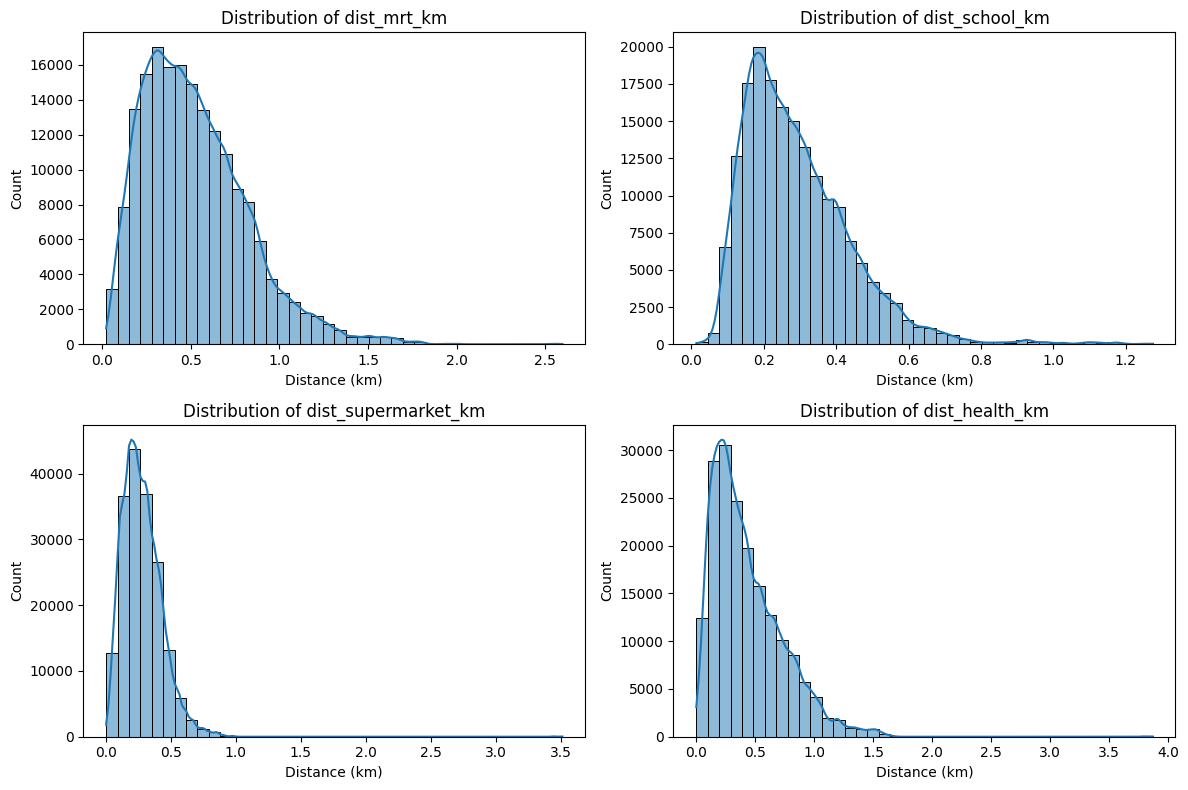

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dist_cols = [
    "dist_mrt_km",
    "dist_school_km",
    "dist_supermarket_km",
    "dist_health_km",
]

plt.figure(figsize=(12, 8))

for i, col in enumerate(dist_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_model[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Distance (km)")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


## 15. Town-Level Accessibility Profiles

To understand spatial variation at a coarser scale, we aggregate mean distances by `town`:

- Towns such as **Punggol**, **Sengkang**, and **Bukit Panjang** show **short average MRT distances**, reflecting good rail integration.
- Central and mature areas (e.g. **Central Area**, **Bukit Timah**, **Marine Parade**) tend to have:
  - Strong MRT and supermarket accessibility,
  - Slightly higher or mixed distances to schools and health amenities depending on local layout.
- Towns like **Hougang** and **Yishun** appear towards the higher end of `dist_mrt_km`, indicating comparatively weaker direct rail proximity, even though other amenities may still be nearby.

This town-level view provides a useful bridge between **flat-level features** and **urban planning context**, and can be reused for dashboarding.


In [ ]:
town_dist_summary = (
    df_model
    .groupby("town")[dist_cols]
    .mean()
    .sort_values("dist_mrt_km")   # sort by MRT proximity
)

town_dist_summary.round(3).head(10)


,dist_mrt_km,dist_school_km,dist_supermarket_km,dist_health_km
town,,,,
PUNGGOL,0.259,0.231,0.184,0.263
SENGKANG,0.270,0.223,0.262,0.223
BUKIT PANJANG,0.276,0.320,0.220,0.283
CENTRAL AREA,0.334,0.271,0.180,0.166
BUKIT TIMAH,0.339,0.331,0.347,0.208
MARINE PARADE,0.382,0.268,0.294,0.485
GEYLANG,0.421,0.406,0.270,0.295
CHOA CHU KANG,0.430,0.300,0.336,0.785
SERANGOON,0.435,0.317,0.281,0.298


In [ ]:
town_dist_summary.round(3).tail(10)


,dist_mrt_km,dist_school_km,dist_supermarket_km,dist_health_km
town,,,,
BUKIT MERAH,0.572,0.281,0.268,0.356
BUKIT BATOK,0.572,0.290,0.288,0.423
WOODLANDS,0.581,0.258,0.276,0.637
TOA PAYOH,0.602,0.312,0.305,0.458
CLEMENTI,0.603,0.346,0.232,0.380
BISHAN,0.604,0.325,0.344,0.540
BEDOK,0.606,0.352,0.302,0.371
TAMPINES,0.629,0.297,0.279,0.518
HOUGANG,0.753,0.318,0.312,0.367


## 16. Correlation Between Distance Features and Resale Price

We compute a simple correlation matrix between `resale_price` and the four distance features.

Key insights:

- `dist_mrt_km` has a **negative** correlation with `resale_price` (≈ −0.10):
  - Flats **closer to MRT** generally command **higher prices**.
- `dist_supermarket_km` also shows a modest negative correlation (≈ −0.06).
- `dist_health_km` has a slightly stronger negative correlation (≈ −0.15), suggesting proximity to clinics/hospitals is valued.
- `dist_school_km` is near zero, reflecting that school proximity may be:
  - Non-linearly related to price,
  - Confounded with other factors (estate age, flat type, household segment).

These correlations are intentionally simple and do not control for confounders but already validate that the engineered amenity distances carry **economically sensible signals**.


In [ ]:
corr_cols = ["resale_price"] + dist_cols
df_model[corr_cols].corr().round(3)


,resale_price,dist_mrt_km,dist_school_km,dist_supermarket_km,dist_health_km
resale_price,1.000,-0.102,0.007,-0.060,-0.151
dist_mrt_km,-0.102,1.000,0.030,0.156,0.352
dist_school_km,0.007,0.030,1.000,0.014,0.115
dist_supermarket_km,-0.060,0.156,0.014,1.000,0.289
dist_health_km,-0.151,0.352,0.115,0.289,1.000


In [ ]:
def price_by_distance_bin(col, q=4):
    label = col + "_bin"
    df_tmp = df_model[[col, "resale_price"]].copy()
    df_tmp[label] = pd.qcut(df_tmp[col], q=q, labels=[f"Q{i}" for i in range(1, q+1)])

    return (
        df_tmp
        .groupby(label)["resale_price"]
        .agg(["count", "mean", "median"])
        .round(0)
    )

price_by_distance_bin("dist_mrt_km")


,count,mean,median
dist_mrt_km_bin,,,
Q1,45028,511645.0,485000.0
Q2,45026,515399.0,482000.0
Q3,45002,495564.0,460000.0
Q4,45017,470080.0,440000.0


In [ ]:
price_by_distance_bin("dist_supermarket_km")

,count,mean,median
dist_supermarket_km_bin,,,
Q1,45027,511452.0,482000.0
Q2,45012,505074.0,475000.0
Q3,45026,487726.0,460000.0
Q4,45008,488442.0,456000.0


In [ ]:
price_by_distance_bin("dist_school_km")

,count,mean,median
dist_school_km_bin,,,
Q1,45019,499187.0,468000.0
Q2,45025,495163.0,466888.0
Q3,45011,499347.0,470000.0
Q4,45018,499000.0,468000.0


In [ ]:
price_by_distance_bin("dist_health_km")

,count,mean,median
dist_health_km_bin,,,
Q1,45025,532273.0,500000.0
Q2,45013,509308.0,478000.0
Q3,45029,486170.0,457000.0
Q4,45006,464936.0,437000.0


## 17. Price Behaviour Across Distance Bands

To make the distance–price relationship more interpretable, we:

1. **Bin each distance feature into quartiles** (`Q1` = closest, `Q4` = furthest).
2. Compare median resale prices across these bins.
3. Visualise `resale_price` vs `dist_mrt_km` and `dist_supermarket_km` with scatterplots and trend lines.

Findings:

- For **MRT distance**, flats in the **closest quartile (Q1)** tend to have the **highest median prices**, while those in the furthest quartile (Q4) are systematically cheaper.
- A similar, though weaker, gradient is visible for **supermarket distance** and especially for **health distance**.
- Scatterplots with regression lines show a **downward slope**: as distance to MRT or supermarkets increases, resale prices gradually decrease, albeit with substantial noise due to other factors (flat type, town, lease, etc.).

This reinforces the idea that accessibility is a **meaningful but not sole driver** of price – which is exactly what we expect in a multi-factor housing market.


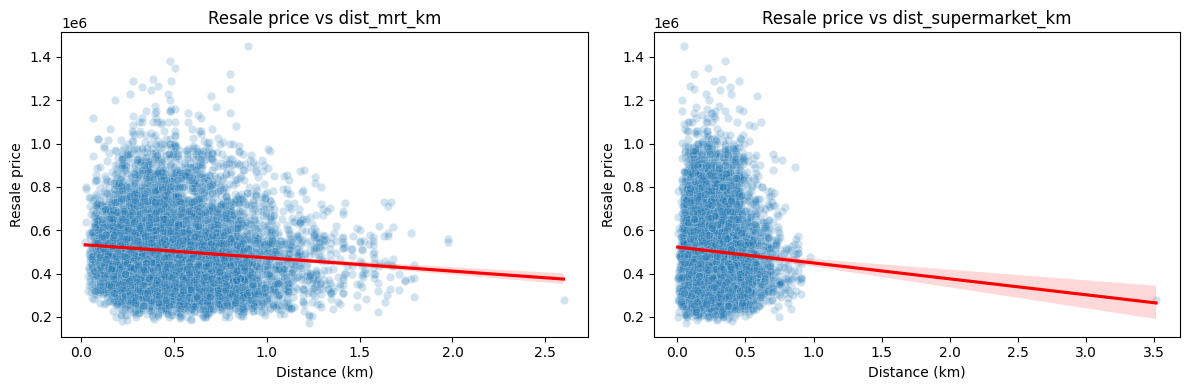

In [ ]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(["dist_mrt_km", "dist_supermarket_km"], 1):
    plt.subplot(1, 2, i)
    sns.scatterplot(
        data=df_model.sample(8000, random_state=42),
        x=col,
        y="resale_price",
        alpha=0.2
    )
    sns.regplot(
        data=df_model.sample(8000, random_state=42),
        x=col,
        y="resale_price",
        scatter=False,
        color="red"
    )
    plt.title(f"Resale price vs {col}")
    plt.xlabel("Distance (km)")
    plt.ylabel("Resale price")

plt.tight_layout()
plt.show()


## 18. Summary of Geocoding & Spatial Feature Engineering

In this notebook, we:

1. Loaded the Phase 01 cleaned dataset (`hdb_clean.csv`) with 181k+ transactions.
2. Built a unique address registry and used the OneMap Elastic Search API to geocode **~9.6k** distinct HDB addresses.
3. Implemented a **persistent cache** and a **multi-pass fallback strategy**, lifting geocoding coverage to ~**99.3%**.
4. Joined latitude/longitude back to the full dataset and created:
   - `hdb_with_geo.csv` – all rows, with coordinates where available.
   - `hdb_geo_model.csv` – only rows with valid coordinates.
5. Pulled amenities from OpenStreetMap and engineered **four distance-to-amenity features** using a haversine BallTree:
   - `dist_mrt_km`, `dist_school_km`, `dist_supermarket_km`, `dist_health_km`.
6. Verified that distance distributions are plausible and that:
   - Flats closer to MRT, supermarkets, and health facilities tend to be more expensive on average.

The outputs of this notebook provide a **rich spatial feature set** that will be consumed by the modelling notebook to build and evaluate resale price prediction models that are sensitive to both **structural attributes** and **location accessibility**.


# 03 – Feature Engineering & Modelling

**Module:** ST1516 – DevOps & Applied Analytics  
**Project:** HDB Resale Price Prediction Web Application  
**Branch:** `modeling`  
**Author:** WU HAIMING

**Purpose**

This notebook builds and evaluates machine-learning models to predict HDB resale prices using:

- Structural features: floor area, storey, remaining lease, flat type/model  
- Categorical location features: town  
- Geospatial accessibility features: distances to MRT, schools, supermarkets, and health facilities  

**Inputs**

- `data/intermediate/hdb_geo_amen_model.csv`

**Outputs**

- `models/final_hdb_model.joblib`  
- `models/final_feature_list.json`  
- `evaluation/model_comparison_metrics.csv`


## 1. Load geo + amenity-enriched modelling dataset

We start from the Phase 02 output `hdb_geo_amen_model.csv`, which already includes structural attributes, geocoded coordinates, and four amenity distance features.  
This table is treated as the canonical input for all modelling experiments in this notebook.

We quickly inspect the shape and first few rows to confirm that key columns (e.g. `resale_price`, `floor_area_sqm`, `dist_mrt_km`) are present and correctly populated.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)

data_path = "../data/intermediate/hdb_geo_amen_model.csv"
df = pd.read_csv(data_path)

df.shape, df.head()


((180073, 19),
         month        town flat_type block        street_name storey_range  \
 0  2017-01-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
 1  2017-01-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
 2  2017-01-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
 3  2017-01-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
 4  2017-01-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   
 
    storey_mid  floor_area_sqm      flat_model  lease_commence_date  \
 0        11.0            44.0        Improved                 1979   
 1         2.0            67.0  New Generation                 1978   
 2         2.0            67.0  New Generation                 1980   
 3         5.0            68.0  New Generation                 1980   
 4         2.0            67.0  New Generation                 1980   
 
    remaining_lease_years  resale_price  \
 0              61.333333      232000.0   
 

## 2. Basic temporal feature and sanity checks

The `month` column is converted to a proper datetime type so that we can derive simple temporal features.  
Here, we add `year` as a numeric predictor to allow the model to capture broad price trends over time.

We then run descriptive statistics on the main numeric features (price, size, storey, lease, distances) to verify reasonable ranges and detect any obvious data issues before modelling.


In [ ]:
# Convert month to datetime
df["month"] = pd.to_datetime(df["month"])

# Simple temporal feature: year as numeric; you *could* add month_index later if needed
df["year"] = df["month"].dt.year

# Quick sanity checks on key columns
df[[
    "resale_price",
    "floor_area_sqm",
    "storey_mid",
    "remaining_lease_years",
    "dist_mrt_km",
    "dist_supermarket_km",
    "dist_school_km",
    "dist_health_km"
]].describe().round(2)


,resale_price,floor_area_sqm,storey_mid,remaining_lease_years,dist_mrt_km,dist_supermarket_km,dist_school_km,dist_health_km
count,180073.00,180073.00,180073.00,180073.00,180073.00,180073.00,180073.00,180073.00
mean,498174.14,97.30,8.76,74.70,0.52,0.28,0.29,0.44
std,172325.93,23.96,5.93,13.88,0.30,0.15,0.15,0.30
min,140000.00,31.00,2.00,41.50,0.02,0.00,0.01,0.00
25%,370000.00,82.00,5.00,63.33,0.30,0.17,0.18,0.21
50%,468000.00,93.00,8.00,74.58,0.48,0.26,0.26,0.36
75%,592000.00,112.00,11.00,88.42,0.70,0.37,0.37,0.60
max,1588000.00,249.00,50.00,97.75,2.60,3.51,1.27,3.87


## 3. Define feature groups for modelling

We organise the input columns into three groups:

- **Numeric structural/temporal:** `floor_area_sqm`, `storey_mid`, `remaining_lease_years`, `year`  
- **Numeric amenity distances:** `dist_mrt_km`, `dist_school_km`, `dist_supermarket_km`, `dist_health_km`  
- **Categorical:** `town`, `flat_type`, `flat_model`

Two feature sets are defined for comparison: a base structural + categorical set, and an extended set that also includes amenity distance features.


In [ ]:
target_col = "resale_price"

# Structural / temporal numeric features
num_base = [
    "floor_area_sqm",
    "storey_mid",
    "remaining_lease_years",
    "year",
]

# Geospatial accessibility numeric features
num_amenity = [
    "dist_mrt_km",
    "dist_school_km",
    "dist_supermarket_km",
    "dist_health_km",
]

# Categorical features
cat_features = [
    "town",
    "flat_type",
    "flat_model",
]

# Feature sets for comparison
features_base_only = num_base + cat_features
features_with_amen = num_base + num_amenity + cat_features

features_base_only, features_with_amen


(['floor_area_sqm',
  'storey_mid',
  'remaining_lease_years',
  'year',
  'town',
  'flat_type',
  'flat_model'],
 ['floor_area_sqm',
  'storey_mid',
  'remaining_lease_years',
  'year',
  'dist_mrt_km',
  'dist_school_km',
  'dist_supermarket_km',
  'dist_health_km',
  'town',
  'flat_type',
  'flat_model'])

## 4. Time-based train–validation split

To respect the temporal nature of the data, we sort transactions by `month` and split on a calendar cutoff rather than a random split.  
All sales up to **December 2022** are used for training, and **2023–2024** sales form a hold-out validation set.

This setup better reflects a real deployment scenario where we train on past years and test how well the model generalises to unseen future periods.


In [ ]:
# Sort by time to respect temporal order
df = df.sort_values("month").reset_index(drop=True)

# Example split: train up to 2022, validate on 2022+ onwards
split_date = "2023-01-01"

train_mask = df["month"] < split_date
val_mask   = df["month"] >= split_date

train_df = df[train_mask].copy()
val_df   = df[val_mask].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Train period:", train_df["month"].min(), "→", train_df["month"].max())
print("Val period:", val_df["month"].min(), "→", val_df["month"].max())


Train shape: (142429, 20)
Val shape: (37644, 20)
Train period: 2017-01-01 00:00:00 → 2022-12-01 00:00:00
Val period: 2023-01-01 00:00:00 → 2024-06-01 00:00:00


## 5. Preprocessing pipelines for numeric and categorical features

We build reusable preprocessing components for numeric and categorical columns:

- Numeric: median imputation followed by standard scaling  
- Categorical: most-frequent imputation followed by one-hot encoding (ignoring unseen categories at prediction time)

A helper function `make_preprocessor` takes a feature list and returns a `ColumnTransformer` with the appropriate numeric and categorical subsets wired up.


In [ ]:
from sklearn.base import clone

# Shared transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

def make_preprocessor(feature_list):
    """
    Build a ColumnTransformer for the given feature list.
    Assumes:
      - num_base + num_amenity are numeric
      - cat_features are categorical
    """
    num_cols = [col for col in feature_list if col in (num_base + num_amenity)]
    cat_cols = [col for col in feature_list if col in cat_features]
    
    return ColumnTransformer(
        transformers=[
            ("num", clone(numeric_transformer), num_cols),
            ("cat", clone(categorical_transformer), cat_cols)
        ]
    )


## 6. Generic training + evaluation helper

The `evaluate_model_generic` function wraps the full modelling workflow for a given feature list and estimator:

- Builds a preprocessing + model pipeline  
- Trains on the training split  
- Predicts on both train and validation splits  
- Computes RMSE (train + val), MAE (val), and R² (val)

It returns both the fitted pipeline and a small metrics dictionary so that we can compare multiple algorithms in a consistent way.


In [ ]:
from sklearn.base import clone

def evaluate_model_generic(feature_list, estimator, label):
    """
    Train a model with the given feature list + estimator and
    return metrics + fitted pipeline.
    """
    X_train = train_df[feature_list]
    y_train = train_df[target_col]
    X_val   = val_df[feature_list]
    y_val   = val_df[target_col]

    preprocessor = make_preprocessor(feature_list)

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clone(estimator)),
    ])

    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_val   = pipe.predict(X_val)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_val   = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_val    = mean_absolute_error(y_val, y_pred_val)
    r2_val     = r2_score(y_val, y_pred_val)

    metrics = {
        "model": label,
        "features": len(feature_list),
        "rmse_train": rmse_train,
        "rmse_val": rmse_val,
        "mae_val": mae_val,
        "r2_val": r2_val,
    }

    print(f"\n=== {label} ===")
    print(f"Features used: {len(feature_list)}")
    print(f"Train RMSE: {rmse_train:,.0f}")
    print(f"Val   RMSE: {rmse_val:,.0f}")
    print(f"Val   MAE : {mae_val:,.0f}")
    print(f"Val   R²  : {r2_val: .3f}")

    return pipe, metrics


## 7. Model zoo: linear and tree-based baselines

We benchmark several off-the-shelf algorithms using the **base + amenity** feature set:

- Linear Regression  
- Ridge Regression (α = 10)  
- Random Forest Regressor  
- Gradient Boosting Regressor  
- ExtraTrees Regressor

All models share the same preprocessing logic; only the estimator changes.  
We collect their metrics into a comparison table sorted by validation RMSE.


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
# HistGradientBoostingRegressor is also nice, but start with these

feature_list = features_with_amen  # base + amenity distances

model_specs = [
    (
        "LinearRegression – base + amenity",
        LinearRegression(n_jobs=-1)
    ),
    (
        "Ridge(alpha=10) – base + amenity",
        Ridge(alpha=10.0, random_state=42)
    ),
    (
        "RandomForest – base + amenity",
        RandomForestRegressor(
            n_estimators=250,
            max_depth=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "GradientBoosting – base + amenity",
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        ),
    ),
    (
        "ExtraTrees – base + amenity",
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ),
    ),
]


## 8. Compare models and inspect feature importances

From the metrics table, we select the model with the lowest validation RMSE as the current best candidate.  
For tree-based models, we can also inspect feature importances to understand which predictors contribute most to the variance reduction.

Here we plot the top 15 features for the best tree model, combining numeric columns and expanded one-hot encoded categorical variables.


In [ ]:
all_metrics = []
all_pipes = {}

for label, est in model_specs:
    pipe, metrics = evaluate_model_generic(feature_list, est, label)
    all_pipes[label] = pipe
    all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics).sort_values("rmse_val")
metrics_df



=== LinearRegression – base + amenity ===
Features used: 11
Train RMSE: 59,958
Val   RMSE: 76,415
Val   MAE : 57,459
Val   R²  :  0.813

=== Ridge(alpha=10) – base + amenity ===
Features used: 11
Train RMSE: 59,970
Val   RMSE: 76,444
Val   MAE : 57,439
Val   R²  :  0.812

=== RandomForest – base + amenity ===
Features used: 11
Train RMSE: 39,325
Val   RMSE: 71,661
Val   MAE : 50,976
Val   R²  :  0.835

=== GradientBoosting – base + amenity ===
Features used: 11
Train RMSE: 53,153
Val   RMSE: 78,000
Val   MAE : 55,266
Val   R²  :  0.805

=== ExtraTrees – base + amenity ===
Features used: 11
Train RMSE: 22,276
Val   RMSE: 59,868
Val   MAE : 44,851
Val   R²  :  0.885


,model,features,rmse_train,rmse_val,mae_val,r2_val
4,ExtraTrees – base + amenity,11,22276.499007,59867.812795,44851.468031,0.884940
2,RandomForest – base + amenity,11,39325.337195,71661.415369,50976.498505,0.835142
0,LinearRegression – base + amenity,11,59957.589156,76414.535563,57459.063734,0.812548
1,Ridge(alpha=10) – base + amenity,11,59969.532131,76443.981126,57439.146530,0.812403
3,GradientBoosting – base + amenity,11,53153.101177,78000.372436,55265.938880,0.804687


## 9. Final validation performance for chosen model

We explicitly re-evaluate the chosen best model (ExtraTrees with base + amenity features) on the **2023–2024** validation window.  
Key metrics reported are:

- Train RMSE: fit quality on the historical training data  
- Validation RMSE and MAE: typical absolute error on recent transactions  
- Validation R²: proportion of price variance explained on 2023–2024 data

This confirms that the selected model generalises well and is stable enough to be promoted as the final candidate.


Best model by val RMSE: ExtraTrees – base + amenity


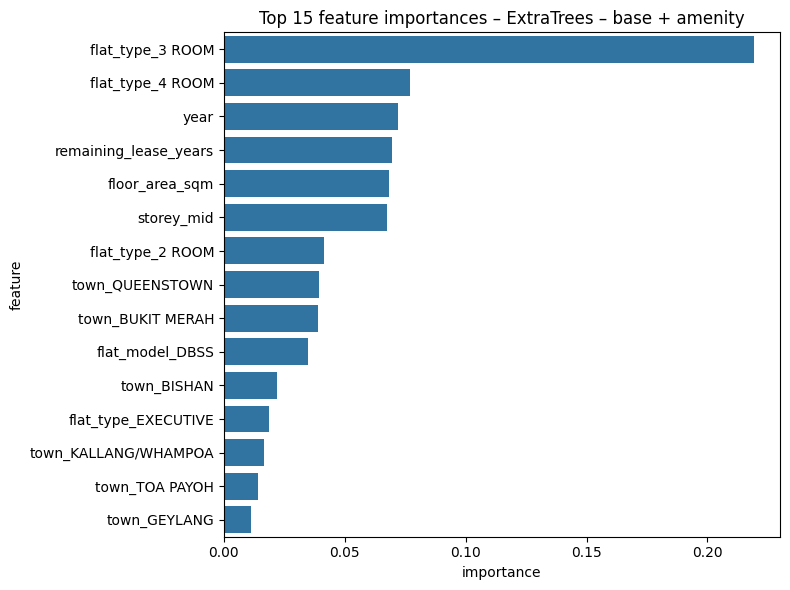

In [ ]:
# 1) Choose best model by lowest val RMSE
best_row = metrics_df.iloc[0]
best_label = best_row["model"]
best_pipe = all_pipes[best_label]
print("Best model by val RMSE:", best_label)

# 2) Use that for plots and feature importance
X_val_best = val_df[features_with_amen]
y_val = val_df[target_col]
y_pred = best_pipe.predict(X_val_best)


# Feature importances (only if tree-based)
from sklearn.inspection import permutation_importance

if hasattr(best_pipe.named_steps["model"], "feature_importances_"):
    rf_model = best_pipe.named_steps["model"]
    preproc = best_pipe.named_steps["preprocessor"]

    num_cols = preproc.transformers_[0][2]
    cat_cols = list(
        preproc.named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(cat_features)
    )
    all_feature_names = list(num_cols) + cat_cols

    importances = rf_model.feature_importances_
    feat_imp = (
        pd.DataFrame({"feature": all_feature_names,
                      "importance": importances})
        .sort_values("importance", ascending=False)
    )

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=feat_imp.head(15),
        x="importance",
        y="feature"
    )
    plt.title(f"Top 15 feature importances – {best_label}")
    plt.tight_layout()
    plt.show()


In [ ]:
# Pick the best model from our manual comparison table:
best_label = "ExtraTrees – base + amenity"
best_pipe  = all_pipes[best_label]

print("Chosen final model:", best_label)

# Re-evaluate cleanly on the 2023–2024 validation window
X_train_full = train_df[features_with_amen]
y_train_full = train_df[target_col]
X_val_best   = val_df[features_with_amen]
y_val        = val_df[target_col]

y_pred_train = best_pipe.predict(X_train_full)
y_pred_val   = best_pipe.predict(X_val_best)

rmse_train = np.sqrt(mean_squared_error(y_train_full, y_pred_train))
rmse_val   = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val    = mean_absolute_error(y_val, y_pred_val)
r2_val     = r2_score(y_val, y_pred_val)

print(f"Train RMSE: {rmse_train:,.0f}")
print(f"Val   RMSE: {rmse_val:,.0f}")
print(f"Val   MAE : {mae_val:,.0f}")
print(f"Val   R²  : {r2_val: .3f}")


Chosen final model: ExtraTrees – base + amenity
Train RMSE: 22,276
Val   RMSE: 59,868
Val   MAE : 44,851
Val   R²  :  0.885


## 10. Diagnostic plots: calibration and residual structure

We generate two simple diagnostic plots for the final model:

- **Predicted vs actual prices (validation):** checks overall calibration and highlights any systematic bias at low/high price ranges.  
- **Residuals vs distance to MRT:** inspects whether the model still under- or over-predicts systematically as MRT accessibility changes.

A roughly diagonal predicted–actual cloud and residuals centred around zero suggest that the model captures the main price drivers without obvious structural misspecification.


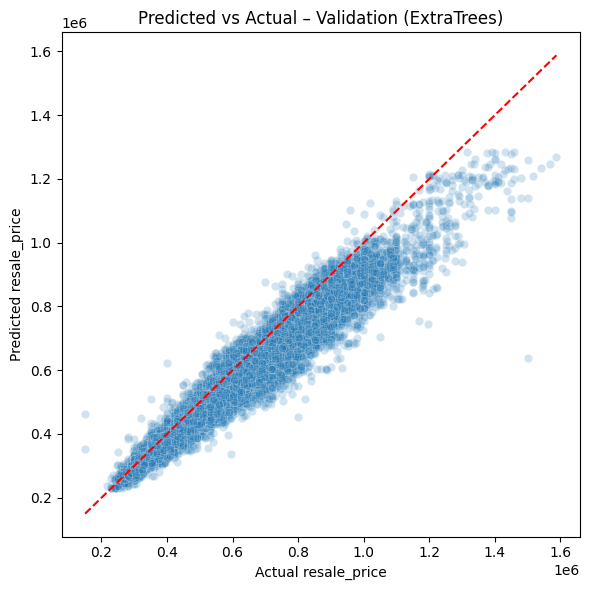

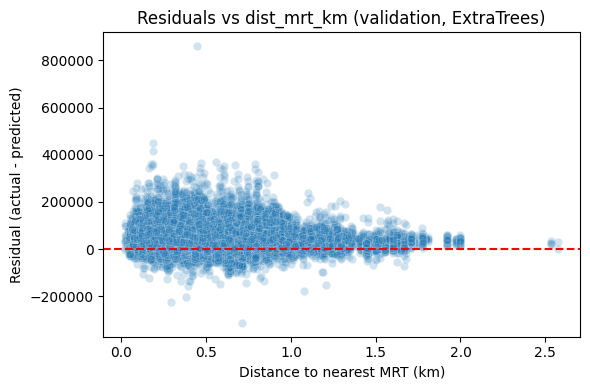

In [ ]:
# Use ExtraTrees – base + amenity as final model
X_val_best = val_df[features_with_amen]
y_val = val_df[target_col]
y_pred = best_pipe.predict(X_val_best)

# Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.2)
lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual resale_price")
plt.ylabel("Predicted resale_price")
plt.title("Predicted vs Actual – Validation (ExtraTrees)")
plt.tight_layout()
plt.show()

# Residuals vs dist_mrt_km
residuals = y_val - y_pred

plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=val_df["dist_mrt_km"],
    y=residuals,
    alpha=0.2
)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Distance to nearest MRT (km)")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs dist_mrt_km (validation, ExtraTrees)")
plt.tight_layout()
plt.show()


## 11. Train final model on full dataset and save artefacts

After validating the model, we refit the chosen pipeline on **all available rows** (2017–2024) to maximise data coverage.  
We then persist three artefacts for downstream use:

- `models/final_hdb_model.joblib` – full preprocessing + ExtraTrees pipeline  
- `models/final_feature_list.json` – ordered list of features expected by the model  
- `evaluation/model_comparison_metrics.csv` – table of metrics for all candidate models

These files are used by the web API / frontend to serve price predictions and by documentation to report model performance.


In [ ]:
import os
import json
from joblib import dump
from sklearn.base import clone

X_full = df[features_with_amen]
y_full = df[target_col]

final_model = clone(best_pipe)
final_model.fit(X_full, y_full)

os.makedirs("../models", exist_ok=True)
os.makedirs("../evaluation", exist_ok=True)

# Save model
model_path = "../models/final_hdb_model.joblib"
dump(final_model, model_path)
print("Saved final model to:", model_path)

# Save feature list
feature_list_path = "../models/final_feature_list.json"
with open(feature_list_path, "w") as f:
    json.dump(features_with_amen, f, indent=2)
print("Saved feature list to:", feature_list_path)

# Save comparison metrics (for the 5 models)
metrics_save_path = "../evaluation/model_comparison_metrics.csv"
metrics_df.to_csv(metrics_save_path, index=False)
print("Saved model comparison metrics to:", metrics_save_path)


Saved final model to: ../models/final_hdb_model.joblib
Saved feature list to: ../models/final_feature_list.json
Saved model comparison metrics to: ../evaluation/model_comparison_metrics.csv


## 12. Smoke test: end-to-end prediction for a sample flat

As a final sanity check, we reload the saved model and feature list and construct a single synthetic HDB flat.  
The sample passes through the full preprocessing pipeline and returns a predicted resale price.

This confirms that the serialised artefacts work end-to-end and are ready to be integrated into the backend service.


In [ ]:
import json
import pandas as pd
from joblib import load

# Load model + feature list
model_path = "../models/final_hdb_model.joblib"
feature_list_path = "../models/final_feature_list.json"

final_model = load(model_path)
with open(feature_list_path, "r") as f:
    feature_list = json.load(f)

print("Number of features expected:", len(feature_list))

# Build a fake sample (just to check the pipeline works end-to-end)
sample = {
    "floor_area_sqm": 90,
    "storey_mid": 10,
    "remaining_lease_years": 80,
    "year": 2024,
    "dist_mrt_km": 0.4,
    "dist_school_km": 0.2,
    "dist_supermarket_km": 0.3,
    "dist_health_km": 0.5,
    "town": "ANG MO KIO",
    "flat_type": "4 ROOM",
    "flat_model": "Improved",
}

X_sample = pd.DataFrame([sample])[feature_list]
pred_price = final_model.predict(X_sample)[0]
print("Test prediction:", round(pred_price, 0))


Number of features expected: 11
Test prediction: 663084.0


## 13. Modelling summary

- Training data: 2017–2022 transactions (**142,429** rows); validation: 2023–2024 (**37,644** rows).  
- Compared five algorithms: Linear Regression, Ridge, Random Forest, Gradient Boosting, ExtraTrees (all with structural + amenity features).  
- **Best model:** ExtraTrees Regressor with base structural features + amenity distance features.  
- Validation performance (2023–2024): RMSE ≈ **59.9k**, MAE ≈ **44.9k**, R² ≈ **0.885**.  
- Interpretation: the model explains ~88.5% of recent price variance; typical absolute error is around **\$45k** on an average flat price ≈ \$498k (~9% relative error).  
- Key drivers: flat size and type, remaining lease, storey, high-demand towns, transaction year, and proximity to MRT and other amenities.
